# 07 – Hyperparameter Tuning

**Project:** Diabetes Prediction ML  
**Seminar:** Advanced Applied Data Science – Goethe University Frankfurt  
**Dataset:** CDC BRFSS 2015 – Diabetes Health Indicators (UCI #891)  
**Target:** `Diabetes_binary` (0 = No Diabetes, 1 = Prediabetes/Diabetes)  
**CRISP-DM phase:** 4 – Modeling · Hyperparameter Tuning & Final Selection

## 1. Purpose

NB06 screened model families, feature representations and imbalance strategies and handed three finalists to this notebook — all at `headline_pool`, `imbalance = none`:

- **MLP** and **LightGBM** — the 1·SE performance tie-band,
- **LogReg-L2** — the interpretable clinical model (not a performance pick),
- plus a **stacking recipe** (MLP + LightGBM), OOF-promising but unconfirmed.

NB07 does four things, each under NB06’s exact discipline (group-aware CV, in-fold scaling, `SEED` fixed, test never loaded):

1. **Tune** each finalist with PR-AUC as the objective.
2. **Diagnose overfitting** via the per-fold **train-vs-validation PR-AUC gap** — something NB06 did not record.
3. **Validate the stack** on out-of-fold predictions of the tuned base learners.
4. **Pick the final candidate**, choose an **operating threshold**, and persist everything for NB08.

**Honest expectation.** NB06 showed every axis plateaus at ~0.43–0.44 PR-AUC — a **data-limited plateau**, likely driven by label noise (undiagnosed diabetics are labelled negative) together with limited feature signal in self-reported survey data, rather than by the choice of model. So tuning is expected to yield small gains; the value here is a robust, well-justified, calibrated final model with a defensible operating point — not a jump in PR-AUC.

In [1]:
# --- package install (same pattern as NB04/NB05/NB06) ---------------------
import importlib.util, subprocess, sys
if importlib.util.find_spec("lightgbm") is None:   # NB07 only uses LightGBM
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])

# --- silence non-actionable convergence/version chatter (as in NB06) ------
import warnings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

# --- stdlib + scientific stack --------------------------------------------
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, uniform, randint

# --- the three finalists + tuning / metrics machinery ---------------------
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV,
                                     cross_validate, cross_val_predict)
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             precision_recall_curve, roc_curve,
                             precision_score, recall_score, f1_score, fbeta_score,
                             confusion_matrix, matthews_corrcoef, balanced_accuracy_score)
from sklearn.calibration import calibration_curve

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
# repo root + shared utilities (single source of truth, identical to NB04/05/06)
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "notebooks").is_dir())
DATA_DIR    = PROJECT_ROOT / "data" / "processed"
NB06_DIR    = PROJECT_ROOT / "outputs" / "nb06"          # read NB06's hand-off
OUTPUT_DIR  = PROJECT_ROOT / "outputs" / "nb07"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = PROJECT_ROOT / "outputs" / "results.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import log_result, make_cv, paired_delta   # same helpers as NB05/NB06

# defensive ledger wrapper: log only the fields the installed log_result accepts
import inspect as _inspect
_LOG_KEYS = set(_inspect.signature(log_result).parameters)
_LOG_KWARGS = any(p.kind == p.VAR_KEYWORD for p in _inspect.signature(log_result).parameters.values())
def safe_log_result(path, **kw):
    if _LOG_KWARGS:
        return log_result(path, **kw)
    keep = {k: v for k, v in kw.items() if k in _LOG_KEYS}
    return log_result(path, **keep)

import sklearn
print(f"sklearn {sklearn.__version__}")
print("output dir:", OUTPUT_DIR)

sklearn 1.8.0
output dir: c:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\nb07


In [3]:
# ---------------------------------------------------------------------
# NB07 configuration (all pre-specified; never tuned post hoc).
# ---------------------------------------------------------------------
with open(DATA_DIR / "feature_meta.json") as f:
    SEED = json.load(f)["seed"]
np.random.seed(SEED)
N_FOLDS = 5

# tuning budget — generous for a thorough search ("best result, even if longer").
# Raise to search harder; lower to save time. LightGBM is cheap (~7 s/fit),
# MLP is slow (~40 s/fit) so it gets fewer trials (early-stopping helps).
N_ITER_LGBM = 80     # RandomizedSearch trials for LightGBM
N_ITER_MLP  = 20     # RandomizedSearch trials for MLP
N_GRID_C    = 21     # LogReg has one knob (C) -> full 1-D grid
FBETA       = 2.0    # operating point: recall-weighted (a missed at-risk person
                     # costs more than a false alarm in screening)

print(f"SEED={SEED} | folds={N_FOLDS} | trials: LightGBM={N_ITER_LGBM}, "
      f"MLP={N_ITER_MLP}, LogReg C-grid={N_GRID_C} | operating beta={FBETA}")

SEED=42 | folds=5 | trials: LightGBM=80, MLP=20, LogReg C-grid=21 | operating beta=2.0


## 2. Data, carried decisions, and NB06 hand-off

The data and feature set are loaded exactly as in NB06. Two decisions are **carried over unchanged** (they were settled there, not re-opened here):

- **Feature set = `headline_pool`** (raw 21 + `BMI²`). NB06 §8: it captures the entire feature gain — expansion helps linear models, is neutral/harmful for trees — and the L1/EN selectors’ strongest coefficients concentrate on the same signals. `fullpool_L1` topped the raw list by only +0.0001 (noise) and is exploratory.
- **Imbalance = `none`.** NB06 §6: `native` ties on ranking (+0.0002, within noise) but decalibrates badly (Brier 0.097 → 0.171); every resampler is worse. Imbalance is handled by the **metric and the threshold**, not by resampling.

In [4]:
# canonical features + NB05 feature sets (single source of truth)
with open(DATA_DIR / "feature_meta.json") as f:
    feature_meta = json.load(f)
ALL_FEATURES = feature_meta["all_features"]                       # raw 21
with open(DATA_DIR / "feature_sets_nb05.json") as f:
    HEADLINE_POOL = json.load(f)["headline_pool"]                 # raw21 + BMI_squared

X_train_raw = pd.read_parquet(DATA_DIR / "X_train.parquet")[ALL_FEATURES]
X_cand      = pd.read_parquet(DATA_DIR / "X_train_candidates.parquet")
y_train     = pd.read_parquet(DATA_DIR / "y_train.parquet").squeeze("columns")

# CARRIED FROM NB06: headline_pool feature matrix, imbalance handled via metric/threshold
X = X_cand[HEADLINE_POOL]
groups = pd.util.hash_pandas_object(X_train_raw, index=False).values   # raw-21 profile hash
prevalence = float(y_train.mean())

# NB06 hand-off (finalists + stacking recipe)
with open(NB06_DIR / "nb06_finalists.json") as f:
    nb06 = json.load(f)

# fail loud if the test set ever leaks in
assert "X_test" not in dir() and "y_test" not in dir(), "TEST DATA MUST NOT BE LOADED"
assert set(HEADLINE_POOL).issubset(X_cand.columns), "headline pool drifted"

# validate the NB06 hand-off agrees with what NB07 assumes
# (feature_set / imbalance live INSIDE each finalist row, not at top level)
_fin = nb06["tuning_finalists"]
assert all(r["feature_set"] == "headline_pool" for r in _fin), "NB06 finalists not on headline_pool"
assert all(r["imbalance"]   == "none"          for r in _fin), "NB06 finalists not at imbalance=none"
assert "stacking_recipe" in nb06, "NB06 stacking_recipe missing"

print(f"n_samples={len(X):,} | headline_pool features={X.shape[1]} | "
      f"unique groups={len(set(groups)):,} | prevalence={prevalence:.4f}")
print("NB06 tuning finalists :", [r["model"] for r in nb06["tuning_finalists"]])
print("NB06 stacking recipe  :", nb06.get("stacking_recipe", {}).get("base_learners"))

n_samples=202,943 | headline_pool features=22 | unique groups=182,337 | prevalence=0.1393
NB06 tuning finalists : ['MLP', 'LightGBM', 'LogReg-L2']
NB06 stacking recipe  : ['MLP', 'LightGBM']


In [5]:
# ---------------------------------------------------------------------
# Fold partition: rebuilt with the SAME make_cv(seed) + groups as NB06, so the
# folds are byte-identical -> the reproducibility check below must match NB06.
# ---------------------------------------------------------------------
cv = make_cv(seed=SEED)
splits = list(cv.split(np.zeros(len(y_train)), y_train, groups))
assert len(splits) == N_FOLDS
print("per-fold validation prevalence:", [f"{y_train.iloc[va].mean():.4f}" for _, va in splits])

# PR-AUC is primary; ROC-AUC + Brier are diagnostics. neg_brier_score is built-in
# (positive Brier = -score). return_train_score gives the overfitting gap for free.
SCORING = {"pr_auc": "average_precision", "roc_auc": "roc_auc", "brier": "neg_brier_score"}

def make_pipe(estimator, scale):
    # in-fold StandardScaler for linear/MLP; bare estimator for trees (matches NB06)
    steps = ([("scale", StandardScaler())] if scale else []) + [("model", estimator)]
    return Pipeline(steps)

def cv_summary(cvres, label):
    # mean validation metrics + the train-vs-validation PR-AUC gap (overfitting signal)
    pr, tr = cvres["test_pr_auc"], cvres["train_pr_auc"]
    return {"label": label, "pr_auc_mean": float(pr.mean()), "pr_auc_std": float(pr.std()),
            "roc_auc_mean": float(cvres["test_roc_auc"].mean()),
            "brier_mean": float(-cvres["test_brier"].mean()),
            "train_pr_auc": float(tr.mean()), "gap": float(tr.mean() - pr.mean()),
            "pr_folds": pr}

def search_summary(search, label):
    # same fields, pulled from a fitted *SearchCV best config
    bi, r = search.best_index_, search.cv_results_
    folds = np.array([r[f"split{k}_test_pr_auc"][bi] for k in range(N_FOLDS)])
    return {"label": label, "pr_auc_mean": float(r["mean_test_pr_auc"][bi]),
            "pr_auc_std": float(r["std_test_pr_auc"][bi]),
            "roc_auc_mean": float(r["mean_test_roc_auc"][bi]),
            "brier_mean": float(-r["mean_test_brier"][bi]),
            "train_pr_auc": float(r["mean_train_pr_auc"][bi]),
            "gap": float(r["mean_train_pr_auc"][bi] - r["mean_test_pr_auc"][bi]),
            "pr_folds": folds}

def oof_proba(estimator):
    # group-aware out-of-fold P(positive); estimator is cloned + refit per fold
    return cross_val_predict(estimator, X, y_train, cv=splits,
                             method="predict_proba", n_jobs=1)[:, 1]

def _py(v):
    # numpy/tuple -> json-serialisable
    if isinstance(v, np.integer): return int(v)
    if isinstance(v, np.floating): return float(v)
    if isinstance(v, tuple): return list(v)
    return v

print("CV splits, scoring and helpers ready.")

per-fold validation prevalence: ['0.1393', '0.1393', '0.1393', '0.1393', '0.1393']
CV splits, scoring and helpers ready.


## 3. Reproducibility check

Before tuning, confirm the folds are identical to NB06: the **untuned LogReg-L2** at NB06’s settings must reproduce its NB06 PR-AUC (~0.4208). If it does, every score in this notebook is directly comparable to NB06.

In [6]:
logreg_default = make_pipe(
    LogisticRegression(penalty="l2", max_iter=2000, random_state=SEED), scale=True)
_repro = cv_summary(cross_validate(logreg_default, X, y_train, cv=splits, scoring=SCORING,
                                   return_train_score=True, n_jobs=1), "LogReg-L2 (NB06 default)")
print(f"LogReg-L2 default PR-AUC = {_repro['pr_auc_mean']:.4f}   (NB06 reported ~0.4208)")
print(f"folds identical to NB06 : {abs(_repro['pr_auc_mean'] - 0.4208) < 0.002}")

LogReg-L2 default PR-AUC = 0.4208   (NB06 reported ~0.4208)
folds identical to NB06 : True


## 4. Tuning protocol — what we optimise, how, and why

**What (objective).** We tune on **PR-AUC** (`average_precision`). It is the metric NB06 used, it is the right target for an imbalanced ranking problem — PR-AUC focuses on precision and recall for the positive class, whereas ROC-AUC (kept only as a secondary diagnostic) is prevalence-invariant, so it can stay high even when precision is poor — the false-positive rate is measured against the dominant negative class, so many false positives barely move it — and it is **threshold-free** — so tuning optimises *how well the model ranks risk*, and the decision threshold is chosen separately afterwards (§7).

**How (search).** `RandomizedSearchCV` / `GridSearchCV` over a `Pipeline` (`StandardScaler → model` for MLP/LogReg, bare model for LightGBM), using the **same group-aware folds** as NB06. The scaler is refit inside every training fold, so there is no leakage. ROC-AUC and Brier are tracked alongside as diagnostics.

**Why each model has the knobs it has — the bias–variance idea.** Tuning balances **capacity** (can the model fit finer patterns?) against **regularisation** (is it forced to stay simple?). We search for the point where *validation* PR-AUC is highest, before the model starts memorising training quirks. Per finalist:

- **LightGBM** (cheap → searched widely): `num_leaves` / `max_depth` set tree **capacity**; `learning_rate` + `n_estimators` the size of the ensemble; `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha/lambda` are **regularisers** that fight overfitting.
- **MLP** (slow → searched modestly, with early stopping): `hidden_layer_sizes` is **capacity**; `alpha` is the **L2 regulariser** (its main overfitting control); `learning_rate_init` / `batch_size` govern optimisation. `early_stopping=True` halts on an internal validation split — prevents overfitting *and* saves time.
- **LogReg-L2** (one knob): `C` is the inverse regularisation strength — small `C` = strongly regularised/simple, large `C` = fits more. A full 1-D grid.

**Detecting overfitting — the train-vs-validation gap.** NB06 recorded only validation (OOF) performance. Here, `return_train_score=True` also gives the **training** PR-AUC per fold, so for every configuration we see the **gap = train − validation**. A large gap (high train, flat/falling validation) is the signature of overfitting; we keep the configuration that maximises *validation* PR-AUC and report the gap as a diagnostic. Given the data-limited plateau, gaps should be modest for well-regularised models — though a stronger learner can still open a visible gap while *improving* validation, as tuned LightGBM does in §5.

In [7]:
# ---------------------------------------------------------------------
# Baselines = the NB06 default of each finalist (so "tuned vs untuned" is exact).
# ---------------------------------------------------------------------
base_lr = cv_summary(cross_validate(
    make_pipe(LogisticRegression(penalty="l2", max_iter=2000, random_state=SEED), True),
    X, y_train, cv=splits, scoring=SCORING, return_train_score=True, n_jobs=1), "LogReg default")

base_lgbm = cv_summary(cross_validate(
    make_pipe(LGBMClassifier(n_estimators=300, verbose=-1, n_jobs=-1, random_state=SEED), False),
    X, y_train, cv=splits, scoring=SCORING, return_train_score=True, n_jobs=1), "LightGBM default")

base_mlp = cv_summary(cross_validate(
    make_pipe(MLPClassifier(hidden_layer_sizes=(64,), max_iter=200,
                            early_stopping=True, random_state=SEED), True),
    X, y_train, cv=splits, scoring=SCORING, return_train_score=True, n_jobs=1), "MLP default")

for b in (base_lr, base_lgbm, base_mlp):
    print(f"{b['label']:18s} PR={b['pr_auc_mean']:.4f}  ROC={b['roc_auc_mean']:.4f}  "
          f"Brier={b['brier_mean']:.4f}  train-val gap={b['gap']:+.4f}")

LogReg default     PR=0.4208  ROC=0.8255  Brier=0.0979  train-val gap=+0.0002
LightGBM default   PR=0.4303  ROC=0.8285  Brier=0.0969  train-val gap=+0.0874
MLP default        PR=0.4309  ROC=0.8294  Brier=0.0968  train-val gap=+0.0146


In [8]:
# ---------------------------------------------------------------------
# LogReg-L2: 1-D grid over C (inverse regularisation strength).
# ---------------------------------------------------------------------
C_grid = np.logspace(-3, 2, N_GRID_C)
gs_lr = GridSearchCV(
    make_pipe(LogisticRegression(penalty="l2", max_iter=2000, random_state=SEED), scale=True),
    {"model__C": C_grid}, scoring=SCORING, refit="pr_auc",
    cv=splits, return_train_score=True, n_jobs=1)
t0 = time.time(); gs_lr.fit(X, y_train)
tuned_lr = search_summary(gs_lr, "LogReg tuned")
print(f"LogReg-L2  best C={gs_lr.best_params_['model__C']:.4g}  "
      f"PR={tuned_lr['pr_auc_mean']:.4f}  gap={tuned_lr['gap']:+.4f}  ({time.time()-t0:.0f}s)")

LogReg-L2  best C=1  PR=0.4208  gap=+0.0002  (52s)


In [9]:
# ---------------------------------------------------------------------
# LightGBM: wide randomised search (capacity + regularisation).
# ---------------------------------------------------------------------
lgbm_pipe = make_pipe(
    LGBMClassifier(verbose=-1, n_jobs=-1, random_state=SEED, subsample_freq=1), scale=False)
lgbm_space = {
    "model__n_estimators":      randint(200, 800),
    "model__learning_rate":     loguniform(1e-2, 2e-1),
    "model__num_leaves":        randint(15, 128),
    "model__max_depth":         [-1, 4, 6, 8, 12],
    "model__min_child_samples": randint(10, 200),
    "model__subsample":         uniform(0.6, 0.4),     # 0.6 .. 1.0
    "model__colsample_bytree":  uniform(0.6, 0.4),
    "model__reg_alpha":         loguniform(1e-3, 1e1),
    "model__reg_lambda":        loguniform(1e-3, 1e1),
}
rs_lgbm = RandomizedSearchCV(lgbm_pipe, lgbm_space, n_iter=N_ITER_LGBM, scoring=SCORING,
                             refit="pr_auc", cv=splits, return_train_score=True,
                             random_state=SEED, n_jobs=1)
t0 = time.time(); rs_lgbm.fit(X, y_train)
tuned_lgbm = search_summary(rs_lgbm, "LightGBM tuned")
print(f"LightGBM   PR={tuned_lgbm['pr_auc_mean']:.4f}  gap={tuned_lgbm['gap']:+.4f}  "
      f"({time.time()-t0:.0f}s)")
print("  best params:", {k.replace('model__',''): _py(v) for k, v in rs_lgbm.best_params_.items()})

LightGBM   PR=0.4371  gap=+0.0297  (2362s)
  best params: {'colsample_bytree': 0.7502331810559776, 'learning_rate': 0.013251752704998034, 'max_depth': 6, 'min_child_samples': 162, 'n_estimators': 774, 'num_leaves': 76, 'reg_alpha': 0.014001191914113755, 'reg_lambda': 0.23085168151108015, 'subsample': 0.6122000999756197}


In [10]:
# ---------------------------------------------------------------------
# MLP: modest randomised search (slow). early_stopping uses an internal
# validation split of the training fold -> no leakage of the CV val fold.
# ---------------------------------------------------------------------
mlp_pipe = make_pipe(
    MLPClassifier(max_iter=300, early_stopping=True, n_iter_no_change=10,
                  validation_fraction=0.1, random_state=SEED), scale=True)
mlp_space = {
    "model__hidden_layer_sizes": [(32,), (64,), (128,), (64, 32), (128, 64), (100,)],
    "model__alpha":              loguniform(1e-5, 1e-1),
    "model__learning_rate_init": loguniform(1e-4, 1e-2),
    "model__batch_size":         [128, 256, 512],
}
rs_mlp = RandomizedSearchCV(mlp_pipe, mlp_space, n_iter=N_ITER_MLP, scoring=SCORING,
                            refit="pr_auc", cv=splits, return_train_score=True,
                            random_state=SEED, n_jobs=1)
t0 = time.time(); rs_mlp.fit(X, y_train)
tuned_mlp = search_summary(rs_mlp, "MLP tuned")
print(f"MLP        PR={tuned_mlp['pr_auc_mean']:.4f}  gap={tuned_mlp['gap']:+.4f}  "
      f"({time.time()-t0:.0f}s)")
print("  best params:", {k.replace('model__',''): _py(v) for k, v in rs_mlp.best_params_.items()})

MLP        PR=0.4317  gap=+0.0094  (1292s)
  best params: {'alpha': 0.002463768595899745, 'batch_size': 512, 'hidden_layer_sizes': [100], 'learning_rate_init': 0.0002465844721448739}


## 5. Tuned vs untuned — did tuning help, and is anything overfitting?

The paired Δ (tuned − default) is tested against **1·SE** (same noise bar as NB06’s tie-band). The **gap** column is the overfitting diagnostic from §4.

In [11]:
rows = []
for base, tuned, name in [(base_lr, tuned_lr, "LogReg-L2"),
                          (base_lgbm, tuned_lgbm, "LightGBM"),
                          (base_mlp, tuned_mlp, "MLP")]:
    d = paired_delta(tuned["pr_folds"], base["pr_folds"])
    rows.append({"model": name,
                 "default_PR": round(base["pr_auc_mean"], 4),
                 "tuned_PR":   round(tuned["pr_auc_mean"], 4),
                 "Δ":          round(d["mean"], 4),
                 "1SE":        round(d["se"], 4),
                 ">1SE":       bool(d["mean"] - d["se"] > 0),
                 "tuned_gap":  round(tuned["gap"], 4),
                 "tuned_ROC":  round(tuned["roc_auc_mean"], 4),
                 "tuned_Brier":round(tuned["brier_mean"], 4)})
cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))

    model  default_PR  tuned_PR      Δ    1SE  >1SE  tuned_gap  tuned_ROC  tuned_Brier
LogReg-L2      0.4208    0.4208 0.0000 0.0000 False     0.0002     0.8255       0.0979
 LightGBM      0.4303    0.4371 0.0068 0.0005  True     0.0297     0.8314       0.0963
      MLP      0.4309    0.4317 0.0008 0.0007  True     0.0094     0.8295       0.0968


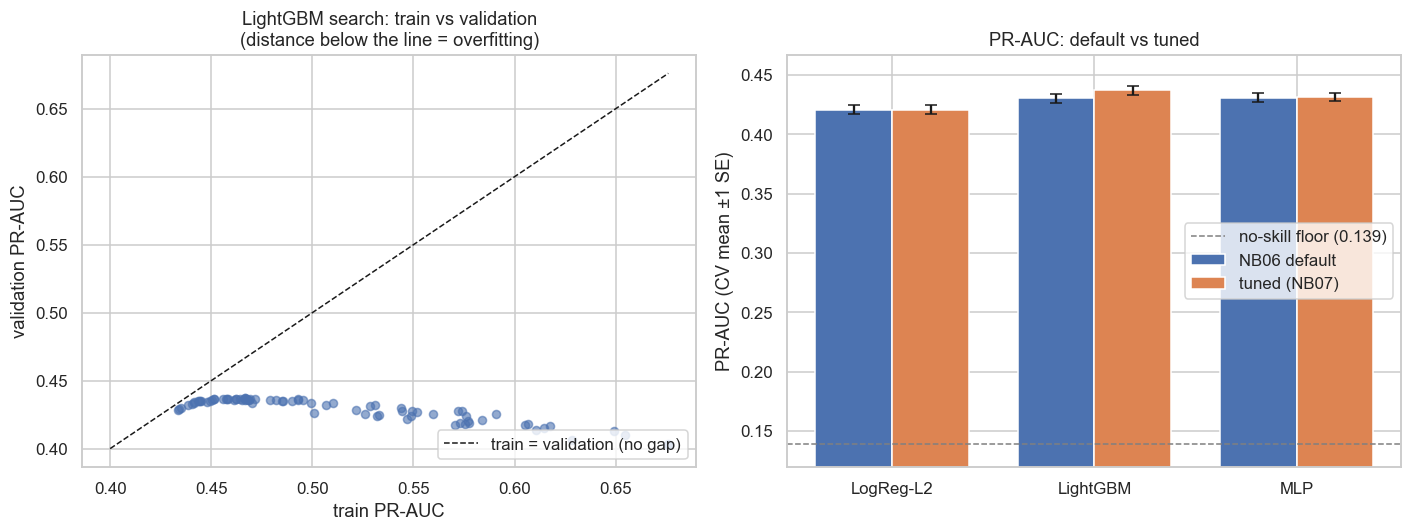

In [12]:
# --- overfitting view + PR-AUC default-vs-tuned (the requested PR-AUC plots) ---
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (left) LightGBM: train vs validation PR-AUC across all searched configs
r = rs_lgbm.cv_results_
ax[0].scatter(r["mean_train_pr_auc"], r["mean_test_pr_auc"], s=28, alpha=0.6)
lo = min(r["mean_test_pr_auc"].min(), 0.40)
hi = max(r["mean_train_pr_auc"].max(), 0.45)
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1, label="train = validation (no gap)")
ax[0].set_xlabel("train PR-AUC"); ax[0].set_ylabel("validation PR-AUC")
ax[0].set_title("LightGBM search: train vs validation\n(distance below the line = overfitting)")
ax[0].legend(loc="lower right")

# (right) PR-AUC default vs tuned, per model, with 1-SE error bars
models = ["LogReg-L2", "LightGBM", "MLP"]
defs = [base_lr["pr_auc_mean"], base_lgbm["pr_auc_mean"], base_mlp["pr_auc_mean"]]
tuns = [tuned_lr["pr_auc_mean"], tuned_lgbm["pr_auc_mean"], tuned_mlp["pr_auc_mean"]]
dse = [b["pr_auc_std"]/np.sqrt(N_FOLDS) for b in (base_lr, base_lgbm, base_mlp)]
tse = [t["pr_auc_std"]/np.sqrt(N_FOLDS) for t in (tuned_lr, tuned_lgbm, tuned_mlp)]
xp = np.arange(len(models)); w = 0.38
ax[1].bar(xp - w/2, defs, w, yerr=dse, capsize=4, label="NB06 default")
ax[1].bar(xp + w/2, tuns, w, yerr=tse, capsize=4, label="tuned (NB07)")
ax[1].axhline(prevalence, ls="--", c="grey", lw=1, label=f"no-skill floor ({prevalence:.3f})")
ax[1].set_xticks(xp); ax[1].set_xticklabels(models)
ax[1].set_ylim(prevalence - 0.02, max(tuns) + 0.03)
ax[1].set_ylabel("PR-AUC (CV mean ±1 SE)"); ax[1].set_title("PR-AUC: default vs tuned")
ax[1].legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "nb07_tuning_overview.png", bbox_inches="tight")
plt.show()

#### Interpretation — what tuning did

Tuning helped **only LightGBM** materially. LogReg is unmoved (the search returns `C = 1`, the default — its L2 strength was already right) and MLP gains a negligible +0.0008. LightGBM, however, gains **+0.0068 (> 1 SE)** — from 0.4303 to ~0.4371 — enough to **break the NB06 tie and overtake MLP** (0.4317); it even passes NB06's *untuned* stack (0.4349). The gain comes from more, slower trees (774 estimators, `learning_rate ≈ 0.013`) at moderate capacity (`num_leaves = 76`, `max_depth = 6`), held in check by regularisation (`min_child_samples = 162`, `subsample ≈ 0.61`, `colsample ≈ 0.75`, L2 ≈ 0.23).

Two honest caveats:
- **The gain stays inside the ~0.43–0.44 plateau** — consistent with NB06, performance appears mainly limited by the available data signal and label noise (undiagnosed cases labelled negative, self-reported features, genuine class overlap), not by the choice of model family alone; this is the small nudge NB06 anticipated, not a breakthrough.
- **The tuned scores are optimistically biased.** Each is the best of 80 (LightGBM) / 20 (MLP) configurations *selected on the same CV folds used to score it* — a winner's-curse effect — so the true gain is likely a little smaller. We deliberately do **not** run nested CV (it would multiply the ~1 h runtime and is redundant): the frozen test set in **NB08 is the unbiased estimate**.

The **train–validation gap** confirms this: LogReg and MLP are near-flat (~0.000 / ~0.009), while tuned LightGBM shows the largest gap (~+0.030: train ~0.467 vs validation ~0.437). Because validation *rose*, this is productive capacity, not harmful overfitting — but it is the configuration to watch on the test set, which is why the regularisers above matter. Selection is on validation PR-AUC alone; the gap is a diagnostic, not a tie-breaker. The search spaces were deliberately broad (LightGBM 80 trials, MLP 20, LogReg a full 1-D grid); the resulting ~1 h runtime was accepted in favour of a thorough search and can be shortened via `N_ITER_*` (§2) with little expected loss. One caveat: the tuned LightGBM sits near the upper edge of the `n_estimators` range (774/800) at a low learning rate, so extending that range *might* add a further marginal gain — but given the plateau and the winner's-curse caveat, any improvement is expected to be within noise (< 0.003), so the range was not extended.

*(On the two PR-AUC numbers: fold-mean PR-AUC — LightGBM ~0.4371 — is used for model **selection**; the global out-of-fold PR-AUC on the curves and for the threshold (~0.4364) is computed on the pooled OOF predictions. They differ slightly because average precision is not fold-additive: the AP of pooled predictions is not the mean of the per-fold APs.)*

## 6. Stacking — does the tuned MLP + LightGBM ensemble beat the best single?

NB06 found the two leaders’ OOF stack reached ~0.4349 (+0.004, >1 SE), while no *third* learner added anything (SVM-Nystroem was ~0.98 error-correlated and even hurt it). Here we rebuild that stack from the **tuned** base learners: their group-aware OOF predictions feed a LogReg meta-learner, cross-validated on the same folds, and we test the gain against the best tuned single. This is the common **OOF-stacking shortcut**: the base out-of-fold predictions are leakage-free per row, but training and scoring the meta-learner on top of them is mildly optimistic (a fully nested stack-CV would be stricter). The stack is therefore treated as an **OOF-promising candidate, not a confirmed winner** — NB08 gives the unbiased verdict.

In [13]:
# tuned out-of-fold predictions for each finalist (cloned + refit per fold)
oof_lr   = oof_proba(gs_lr.best_estimator_)
oof_lgbm = oof_proba(rs_lgbm.best_estimator_)
oof_mlp  = oof_proba(rs_mlp.best_estimator_)

# meta-learner (LogReg) on the two leaders' OOF columns, cross-validated
from sklearn.linear_model import LogisticRegression as _MetaLR
Z = np.column_stack([oof_mlp, oof_lgbm])
oof_stack = np.full(len(y_train), np.nan)
stk_folds = []
for tr, va in splits:
    meta = _MetaLR(max_iter=1000).fit(Z[tr], y_train.values[tr])
    p = meta.predict_proba(Z[va])[:, 1]
    oof_stack[va] = p
    stk_folds.append(average_precision_score(y_train.values[va], p))
stk_folds = np.array(stk_folds)

best_single = max([("MLP", tuned_mlp), ("LightGBM", tuned_lgbm)],
                  key=lambda t: t[1]["pr_auc_mean"])
d_stack = paired_delta(stk_folds, best_single[1]["pr_folds"])
print(f"MLP+LightGBM stack PR-AUC = {stk_folds.mean():.4f}")
print(f"best single = {best_single[0]} ({best_single[1]['pr_auc_mean']:.4f})")
print(f"Δ = {d_stack['mean']:+.4f} (1SE={d_stack['se']:.4f})  ->  "
      f"{'beats best single (>1 SE)' if d_stack['mean'] - d_stack['se'] > 0 else 'within noise'}")

MLP+LightGBM stack PR-AUC = 0.4373
best single = LightGBM (0.4371)
Δ = +0.0002 (1SE=0.0004)  ->  within noise


#### Interpretation — the stack no longer earns its place

In NB06 the MLP + LightGBM stack led (0.4349, +0.004 over the best single) because it combined two *equally strong* models. After tuning that symmetry is gone: LightGBM alone (~0.4371) is the clear leader, and stacking it with the weaker tuned MLP adds only **+0.0002 — well inside 1 SE (0.0004)**. So `STACK_CLEARS_1SE = False`, and the pre-registered rule (§4) correctly makes **LightGBM, not the stack, the primary** candidate. The stack is still persisted with its build recipe as a pre-specified secondary comparison, so NB08 can check once on the test set whether it adds anything — but the lesson is clean: the gain came from **tuning a single model, not from ensembling**.

## 7. Final candidate + Precision–Recall curves

The primary candidate for NB08 is the **MLP+LightGBM stack only if it clears the 1·SE bar over the best single model** (§6); otherwise the best single model itself. **LogReg-L2** travels alongside as the interpretable companion. Because the OOF estimate is mildly optimistic, this is a *nomination*, not a verdict — NB08 confirms it on the frozen test set and can compare it against the best single (also persisted). The PR curves below overlay all tuned finalists against the no-skill floor — the visual form of the headline metric.

Stack clears 1-SE bar  : False
Primary model for NB08 : LightGBM  (OOF PR-AUC 0.4364)
Interpretable companion: LogReg-L2  (OOF PR-AUC 0.4204)


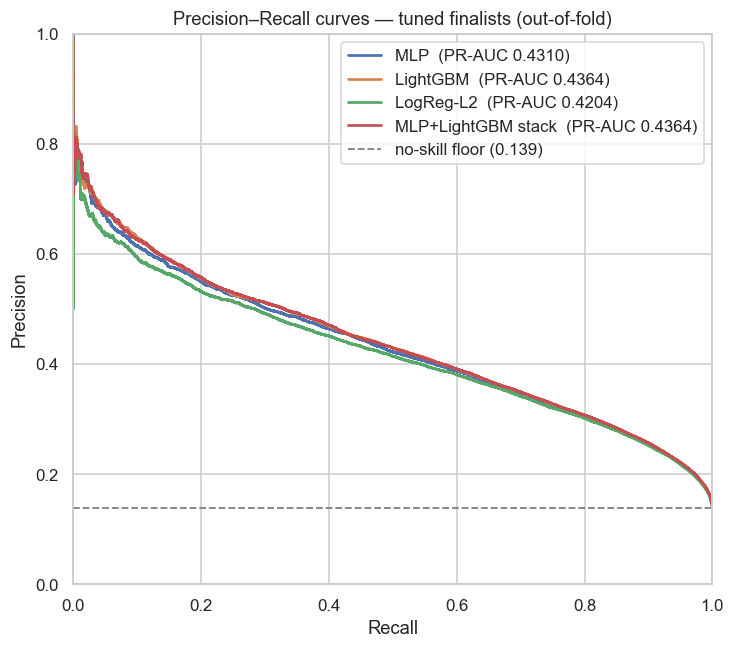

In [14]:
# Primary = MLP+LightGBM stack ONLY if it beats the best single by >1 SE (robust,
# not merely numerically); otherwise the best single model. Matches the §6 rule.
STACK_CLEARS_1SE = bool(d_stack["mean"] - d_stack["se"] > 0)
single_candidates = {"MLP": (tuned_mlp["pr_auc_mean"], oof_mlp),
                     "LightGBM": (tuned_lgbm["pr_auc_mean"], oof_lgbm)}
best_single_name = max(single_candidates, key=lambda k: single_candidates[k][0])
if STACK_CLEARS_1SE:
    primary, final_oof = "MLP+LightGBM stack", oof_stack
else:
    primary, final_oof = best_single_name, single_candidates[best_single_name][1]
print(f"Stack clears 1-SE bar  : {STACK_CLEARS_1SE}")
print(f"Primary model for NB08 : {primary}  (OOF PR-AUC {average_precision_score(y_train, final_oof):.4f})")
print(f"Interpretable companion: LogReg-L2  (OOF PR-AUC {average_precision_score(y_train, oof_lr):.4f})")

# --- PR curves of every tuned finalist (OOF) ---
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for lbl, oof in [("MLP", oof_mlp), ("LightGBM", oof_lgbm),
                 ("LogReg-L2", oof_lr), ("MLP+LightGBM stack", oof_stack)]:
    p, rc, _ = precision_recall_curve(y_train, oof)
    ax.plot(rc, p, lw=1.8, label=f"{lbl}  (PR-AUC {average_precision_score(y_train, oof):.4f})")
ax.axhline(prevalence, ls="--", c="grey", lw=1.2, label=f"no-skill floor ({prevalence:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Precision–Recall curves — tuned finalists (out-of-fold)")
ax.legend(loc="upper right")
plt.savefig(OUTPUT_DIR / "nb07_pr_curves.png", bbox_inches="tight"); plt.show()

## 8. Operating threshold and full classification metrics

PR-AUC measures ranking; deployment needs a **threshold**. We pick it on the OOF predictions of the final model by maximising **F-β (β = 2)** — recall-weighted, because in screening a missed at-risk person is costlier than a false alarm. At that point we report the full clinical metric set (precision, sensitivity/recall, specificity, F1, F2, balanced accuracy, MCC) and the confusion matrix, plus the PR curve with the operating point, the ROC curve and the calibration curve.

In [15]:
prec, rec, thr = precision_recall_curve(y_train, final_oof)
b2 = FBETA ** 2
fbeta_curve = (1 + b2) * prec * rec / (b2 * prec + rec + 1e-12)   # aligned to prec/rec
best_t = float(thr[int(np.nanargmax(fbeta_curve[:-1]))])           # thr has len-1 vs prec/rec
pred = (final_oof >= best_t).astype(int)
tn, fp, fn, tp = confusion_matrix(y_train, pred).ravel()

metrics = {
    "model": primary,
    "threshold": round(best_t, 4),
    "PR_AUC": round(float(average_precision_score(y_train, final_oof)), 4),
    "ROC_AUC": round(float(roc_auc_score(y_train, final_oof)), 4),
    "Brier": round(float(brier_score_loss(y_train, final_oof)), 4),
    "precision": round(float(precision_score(y_train, pred)), 4),
    "recall_sensitivity": round(float(recall_score(y_train, pred)), 4),
    "specificity": round(float(tn / (tn + fp)), 4),
    "F1": round(float(f1_score(y_train, pred)), 4),
    f"F{int(FBETA)}": round(float(fbeta_score(y_train, pred, beta=FBETA)), 4),
    "balanced_acc": round(float(balanced_accuracy_score(y_train, pred)), 4),
    "MCC": round(float(matthews_corrcoef(y_train, pred)), 4),
}
print(json.dumps(metrics, indent=2))
print(f"confusion @ threshold {best_t:.3f}:  TN={tn}  FP={fp}  FN={fn}  TP={tp}")

{
  "model": "LightGBM",
  "threshold": 0.1191,
  "PR_AUC": 0.4364,
  "ROC_AUC": 0.8313,
  "Brier": 0.0963,
  "precision": 0.2921,
  "recall_sensitivity": 0.835,
  "specificity": 0.6725,
  "F1": 0.4328,
  "F2": 0.6088,
  "balanced_acc": 0.7537,
  "MCC": 0.359
}
confusion @ threshold 0.119:  TN=117461  FP=57206  FN=4666  TP=23610


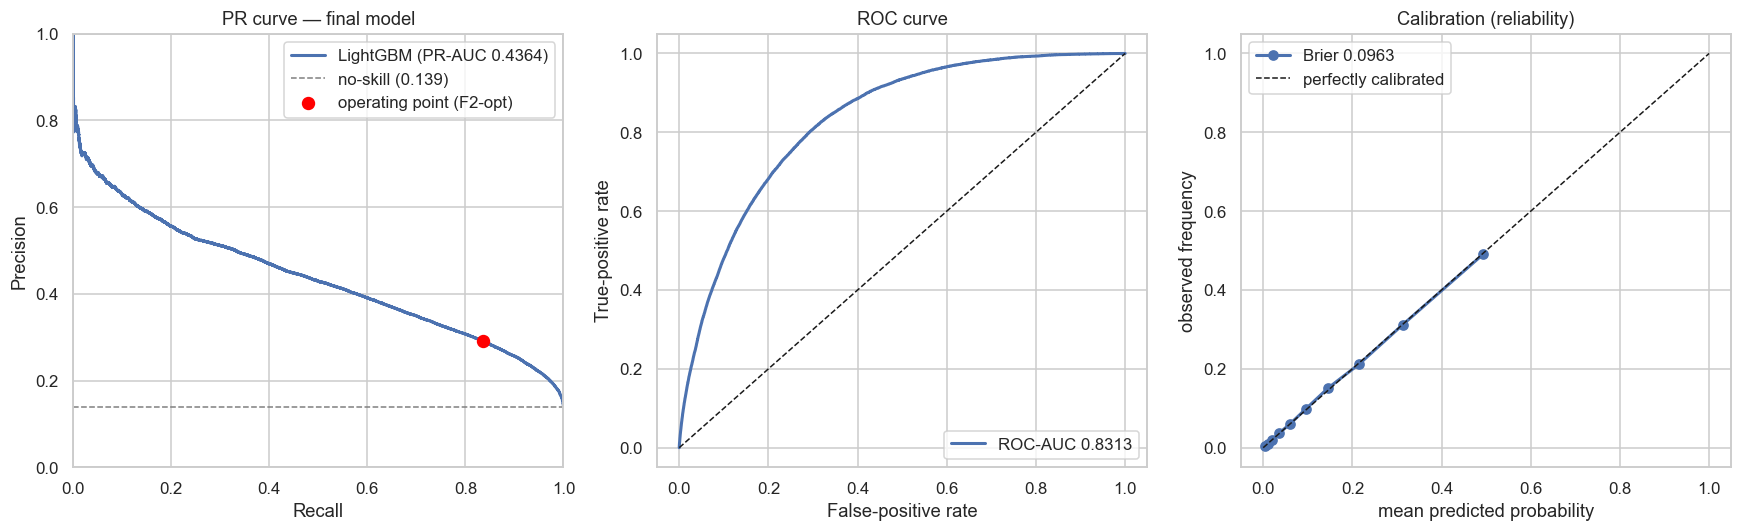

In [16]:
# --- final model: PR curve (with operating point) + ROC + calibration ---
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

p, rc, _ = precision_recall_curve(y_train, final_oof)
ax[0].plot(rc, p, lw=2, label=f"{primary} (PR-AUC {metrics['PR_AUC']:.4f})")
ax[0].axhline(prevalence, ls="--", c="grey", lw=1, label=f"no-skill ({prevalence:.3f})")
ax[0].scatter([metrics["recall_sensitivity"]], [metrics["precision"]], c="red", zorder=5,
              s=60, label=f"operating point (F{int(FBETA)}-opt)")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision"); ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
ax[0].set_title("PR curve — final model"); ax[0].legend(loc="upper right")

fpr, tpr, _ = roc_curve(y_train, final_oof)
ax[1].plot(fpr, tpr, lw=2, label=f"ROC-AUC {metrics['ROC_AUC']:.4f}")
ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_xlabel("False-positive rate"); ax[1].set_ylabel("True-positive rate")
ax[1].set_title("ROC curve"); ax[1].legend(loc="lower right")

frac_pos, mean_pred = calibration_curve(y_train, final_oof, n_bins=10, strategy="quantile")
ax[2].plot(mean_pred, frac_pos, "o-", lw=2, label=f"Brier {metrics['Brier']:.4f}")
ax[2].plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
ax[2].set_xlabel("mean predicted probability"); ax[2].set_ylabel("observed frequency")
ax[2].set_title("Calibration (reliability)"); ax[2].legend(loc="upper left")

plt.tight_layout(); plt.savefig(OUTPUT_DIR / "nb07_final_diagnostics.png", bbox_inches="tight")
plt.show()

#### Interpretation — the operating point

PR-AUC and ROC-AUC describe *ranking*; the F2-optimal threshold (≈ 0.119) turns the ranker into a screening classifier. There the model reaches **recall ≈ 0.84** (it flags ~84 % of true diabetics) at **precision ≈ 0.29**, with specificity ≈ 0.67 and balanced accuracy ≈ 0.75. This is the deliberate screening trade-off: F2 weights recall over precision because a missed at-risk person is costlier than a false alarm (F1-optimal would sit at a higher threshold with more precision but lower recall). The low threshold (well below 0.5) is expected at 14 % prevalence. Crucially, 0.119 is **not an intrinsic optimum** — it is the consequence of the F2 *policy choice* (F2 sets β = 2 in the Fβ formula, weighting recall more strongly than precision); a different cost trade-off (F1, or a fixed precision/recall target) would place it elsewhere. The operating point should follow the clinical use-case, not the data alone.

These at-threshold numbers are **out-of-fold estimates** — the threshold was chosen on the same OOF — so they are mildly optimistic; **NB08 applies this frozen threshold to the untouched test set** for the unbiased operating-point performance.

**Calibration.** Based on the NB07 OOF reliability curve and Brier (~0.10 under `none`, near the diagonal), no post-hoc calibration is selected — the probabilities are usable as-is. This decision is made **here, on OOF evidence**: calibration must *not* be added after seeing the NB08 test results, because the test set is read-only for the final evaluation. (Had the OOF curve been poorly calibrated, the remedy would have been an in-fold `CalibratedClassifierCV`, decided at this point.)

## 9. Persist for NB08

Everything NB08 needs: tuned hyperparameters for all three finalists, the stack recipe, the chosen primary model, the operating threshold and full metrics, and the OOF predictions. **NB08 refits the chosen model on the full training set and evaluates once on the frozen test split — the only unbiased number.**

In [19]:
def _params(search): return {k.replace("model__", ""): _py(v) for k, v in search.best_params_.items()}

payload = {
    "seed": SEED, "n_folds": N_FOLDS, "prevalence": prevalence,
    "feature_set": "headline_pool", "imbalance": "none",
    "estimator_defaults": {
        "LightGBM": {"verbose": -1, "n_jobs": -1, "random_state": SEED, "subsample_freq": 1},
        "MLP": {"max_iter": 300, "early_stopping": True, "n_iter_no_change": 10,
                "validation_fraction": 0.1, "random_state": SEED},
        "LogReg-L2": {"penalty": "l2", "max_iter": 2000, "random_state": SEED},
    },
    "tuned": {
        "LogReg-L2": {"role": "interpretability", "params": _params(gs_lr),
                      "pr_auc": round(tuned_lr["pr_auc_mean"], 4),
                      "roc_auc": round(tuned_lr["roc_auc_mean"], 4),
                      "brier": round(tuned_lr["brier_mean"], 4), "gap": round(tuned_lr["gap"], 4)},
        "LightGBM": {"role": "performance", "params": _params(rs_lgbm),
                     "pr_auc": round(tuned_lgbm["pr_auc_mean"], 4),
                     "roc_auc": round(tuned_lgbm["roc_auc_mean"], 4),
                     "brier": round(tuned_lgbm["brier_mean"], 4), "gap": round(tuned_lgbm["gap"], 4)},
        "MLP": {"role": "performance", "params": _params(rs_mlp),
                "pr_auc": round(tuned_mlp["pr_auc_mean"], 4),
                "roc_auc": round(tuned_mlp["roc_auc_mean"], 4),
                "brier": round(tuned_mlp["brier_mean"], 4), "gap": round(tuned_mlp["gap"], 4)},
    },
    "stack": {"base_learners": ["MLP", "LightGBM"], "meta_learner": "LogisticRegression",
              "pr_auc": round(float(stk_folds.mean()), 4),
              "delta_vs_best_single": round(d_stack["mean"], 4),
              "beats_best_single_1se": bool(d_stack["mean"] - d_stack["se"] > 0),
              "status": "secondary pre-specified comparison; not promoted in NB07 because the gain over tuned LightGBM did not clear 1-SE",
              "training_protocol": (
                  "Build the final stack as follows: (1) load the tuned-base OOF columns saved in "
                  "nb07_tuned_oof.parquet (oof_mlp, oof_lgbm) and fit the LogReg meta-learner on them "
                  "against y_train; (2) refit the tuned MLP and tuned LightGBM (params under 'tuned') "
                  "on the FULL training set; (3) predict the test set with both refit base learners; "
                  "(4) feed those two test probability columns into the fitted meta-learner. "
                  "NEVER train the meta-learner on in-sample base predictions — only on OOF.")},
    "final_for_nb08": {"primary": primary, "companion": "LogReg-L2",
                       "best_single_for_comparison": {
                           "name": best_single_name,
                           "pr_auc": round(single_candidates[best_single_name][0], 4)},
                       "operating_threshold": round(best_t, 4), "operating_metrics": metrics},
    "note": "all numbers are CV/OOF and mildly optimistic; NB08 on the frozen test set is the only unbiased estimate",
}
with open(OUTPUT_DIR / "nb07_finalists.json", "w") as f:
    json.dump(payload, f, indent=2, default=float)

pd.DataFrame({"y_true": y_train.values, "oof_mlp": oof_mlp, "oof_lgbm": oof_lgbm,
              "oof_logreg": oof_lr, "oof_stack": oof_stack}).to_parquet(
    OUTPUT_DIR / "nb07_tuned_oof.parquet")
cmp_df.to_csv(OUTPUT_DIR / "nb07_tuning_comparison.csv", index=False)

# log tuned finalists + stack to the shared ledger (notebook='nb07')
for name, t in [("LogReg-L2", tuned_lr), ("LightGBM", tuned_lgbm), ("MLP", tuned_mlp)]:
    safe_log_result(RESULTS_CSV, notebook="nb07", model=name,
                    pr_auc_mean=t["pr_auc_mean"], pr_auc_std=t["pr_auc_std"],
                    roc_auc_mean=t["roc_auc_mean"], feature_set="headline_pool",
                    imbalance="none", n_folds=N_FOLDS, seed=SEED, pr_auc_folds=t["pr_folds"])
safe_log_result(RESULTS_CSV, notebook="nb07", model="MLP+LightGBM_stack",
                pr_auc_mean=float(stk_folds.mean()), pr_auc_std=float(stk_folds.std()),
                roc_auc_mean=float("nan"), feature_set="headline_pool",
                imbalance="none", n_folds=N_FOLDS, seed=SEED, pr_auc_folds=stk_folds)

print("Saved to", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob("nb07_*")):
    print("  ", p.name)

Saved to c:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\nb07
   nb07_final_diagnostics.png
   nb07_finalists.json
   nb07_pr_curves.png
   nb07_tuned_oof.parquet
   nb07_tuning_comparison.csv
   nb07_tuning_overview.png


## 10. Summary & outlook

1. **Same protocol as NB06** — identical group-aware folds (reproducibility check passes), in-fold scaling, `imbalance = none`, `headline_pool`, test never loaded.
2. **Tuned on PR-AUC**, with ROC-AUC and Brier tracked, and the **train-vs-validation gap** added as an explicit overfitting diagnostic.
3. **Tuning helped only LightGBM materially.** LogReg (best `C` = 1) and MLP barely moved (Δ ≤ +0.001), but LightGBM gained **+0.0068** (> 1 SE), overtaking MLP to become the best single (~0.4371) — it even passes NB06's untuned stack. The gain stays inside the ~0.43–0.44 plateau, so this supports NB06's data-limited reading (limited feature signal, self-reported variables, label noise and class overlap, rather than model choice alone); this is the small nudge NB06 anticipated. LightGBM also shows the largest **train–validation gap** (~+0.030 — more capacity, held in check by regularisation); the others are near-flat. Since the gain is a CV-selected best, it is mildly optimistic — NB08 confirms whether ~0.437 holds on the frozen test.
4. **Stack — not promoted.** The tuned MLP + LightGBM stack was re-validated on OOF but did **not** clear the 1·SE bar over tuned LightGBM (+0.0002, within noise). LightGBM therefore remains the primary NB08 candidate; the stack is persisted only as a pre-specified secondary comparison, to be checked once on the test set.
5. **Selected model: LightGBM is the primary NB08 candidate**, chosen on the best CV PR-AUC among the tuned singles (the stack did not clearly outperform it). It travels with an interpretable LogReg companion and a pre-chosen F2 operating threshold; all parameters, the stack recipe and metrics are persisted for NB08.

**NB08** refits the chosen model on the full training set and evaluates **once** on the frozen test split — the only unbiased estimate of generalisation.